In [5]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

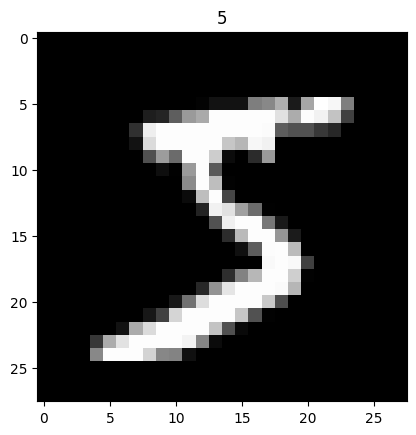

In [6]:
# Load dataset to train and test set
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# example
plt.imshow(X_train[0], cmap="gray")
plt.title(f"{y_train[0]}")
plt.show()

In [7]:
# Check for the shape of the data
assert X_train.shape == (60000, 28, 28)
assert X_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [8]:
print(X_train[0])

"""

-> Since the pixel values are in range of 0-255 which can make model bias while training.
-> To overcome this normalizing these values is a better option

"""

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

'\n\n-> Since the pixel values are in range of 0-255 which can make model bias while training.\n-> To overcome this normalizing these values is a better option\n\n'

In [9]:
# Divide by the highest number value to get a range of 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# Since the image is in grayscale ( Width * height ) and CNN requires a 3d array ( Width * height * channels )
# we are going to convert the matrix to tensor to include the channel for the image.
X_train = X_train[..., None]
X_test = X_test[..., None]

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Flatten

In [12]:
"""

Sequential: Stack of layers added on top of each other

First Layer (Base Layer):
    -> Conv2D: 
        - Outputs 32 feature maps
        - Each filter is of size (3x3)
        - ReLU for non-linearity
        - input shape (28, 28, 1)
    
    -> MaxPooling2D:
        - Basically selects every 2x2 matrix in the each feature map and returns the max value.

Second Layer (Finds more information):
    -> Conv2D:
        - Outputs 64 feature maps (Increased as deeper layers can get more complex patterns then the upper layers)
        - Each filter is of size (3x3)
        - ReLU for non-linearity
        - No input shape as it already has it in above layers
        
    -> MaxPooling2D:
        - Basically selects every 2x2 matrix in the each feature map and returns the max value.

We Flatten before entering deep layers as they reuqire vector shape array rather than 3d array.

Third Layer (Deep learning begins here):
    -> Dense:
        - 128 neurons

Fourth Layer (Output Layer): 
    -> Dense:
        - 10 neurons, each indicating 0-9 digits
        - softmax, as it counts probabilties and the highest one is selected representing the digit.
        
"""

cnn = Sequential([
    Conv2D(32, (3, 3), activation = "relu", input_shape = (28, 28, 1)), 
    MaxPooling2D((2, 2)), 
    Conv2D(64, (3, 3), activation = "relu"),
    MaxPooling2D((2, 2)), 
    Flatten(),
    Dense(128, activation = "relu"),
    Dense(10, activation = "softmax")
])

E:\Education\Projects\Industry-related\Machine Learning\Image Recognition\Handwritten-Digit-Recognition\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
"""
What happens during each epoch:
    - Forward pass:
        The model predicts outputs for all training samples.
    
    - Loss computation:
        It compares predictions with actual labels using the loss function.
    
    - Backward pass (Backpropagation):    
        It calculates how much each weight contributed to the error.

    - Weight update (via optimizer):
        The optimizer (e.g., Adam) adjusts the weights to reduce the loss.

"""
cnn.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Selects the best model and saves it during training
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "HDRM.h5", # Model name
    monitor = "val_loss", # Monitor for validation loss improvements
    save_best_only=True,
    mode = "min", # Look out for minimum losses
    verbose = 1 # Display callbacks
)

# Make 5 iterations over the dataset to learn complex patterns
# Leave 10% data for validation
cnn.fit(X_train, y_train, epochs=5, validation_split=0.1, callbacks=[checkpoint])

Epoch 1/5
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9981 - loss: 0.0059
Epoch 1: val_loss improved from inf to 0.03830, saving model to HDRM.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9928 - val_loss: 0.0383
Epoch 2/5
1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9991 - loss: 0.0032
Epoch 2: val_loss did not improve from 0.03830
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9907 - val_loss: 0.0479
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9980 - loss: 0.0055
Epoch 3: val_loss did not improve from 0.03830
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9922 - val_loss: 0.0499
Epoch 4/5
1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9993 - loss: 0.0024
Epoch 4: val_loss did not improve from 0.03830
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9915 - val_loss: 0.0541
Epoch 5/5
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9988 - loss: 0.0040
Epoch 5: val_loss did not im

In [45]:
from tensorflow.keras.models import load_model
model = load_model("HDRM.h5") # Load best saved model

# Test Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9877 - loss: 0.0492
Test Loss: 0.0355205200612545
Test Accuracy: 0.9912999868392944


In [59]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
# Predict

"""

-> Forms a batch (1, 28, 28, 1) for each image automatically, as model.predict() expects a batch
-> np.argmax will get the index of maximum probability in the 2d array
-> We use axis = 1 as the 2D array will have rows and columns where each row is one image and columns represent the 10 probs.

"""

y_pred_probs = model.predict(X_test) # Shape: (10000, 10) as there 10000 images and each image will get a vector of 10 probs.
y_pred = np.argmax(y_pred_probs, axis = 1)

print(f"Classification Report: \n{classification_report(y_test, y_pred)}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



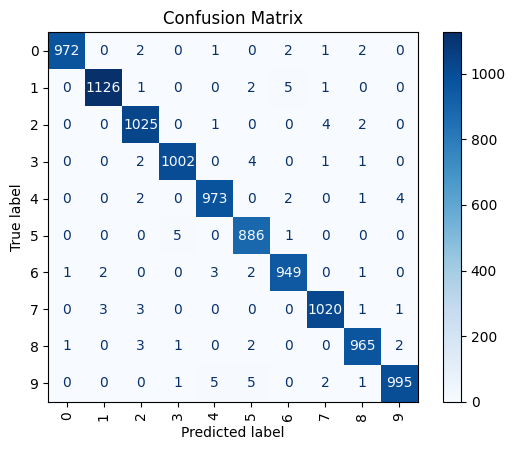

In [67]:
cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = range(10))

display_cm.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix")
plt.show()